In [34]:
import pickle

feature_bow = pickle.load(open('model/feature-bow.p', 'rb'))
model_nb = pickle.load(open('model/model-nb.p', 'rb'))
model_nn = pickle.load(open('model/model-nn.p', 'rb'))

d:\Downloads\Perkuliahan\Semester 5\Aplikasi Web\Pertemuan_5\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 0.22.2.post1 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Downloads\Perkuliahan\Semester 5\Aplikasi Web\Pertemuan_5\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 0.22.2.post1 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Downloads\Perkuliahan\Semester 5\Aplikasi Web\Pertemuan_5\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWar

In [35]:
import pandas as pd

data = pd.read_csv('data/bitcoin2_clean.csv')

In [36]:
def predict_sentiment(sent):
    #feature extraction
    text_feature = feature_bow.transform([sent])
    #predict 
    return model_nb.predict(text_feature)[0]


In [37]:
data['sentiment'] = data.full_text.apply(predict_sentiment)
data

,full_text,sentiment
0,cathie wood says smart investors need to start...,positive
1,bitcoin block growth gives the nft a living ...,negative
2,yeah this trend has been going on for a while...,neutral
3,you can go back in time and meet your self\n\...,positive
4,fiat supply can expand\nbitcoin supply cannot\...,positive
...,...,...
635,soft jobs data k vs k expected just slashed r...,neutral
636,theres definitely something worth paying att...,neutral
637,there are around m fiat millionaires,negative
638,the fellowship will continue to grow its alre...,positive


In [38]:
data.to_csv('data/bitcoin2_clean_sentiment.csv', index=False)

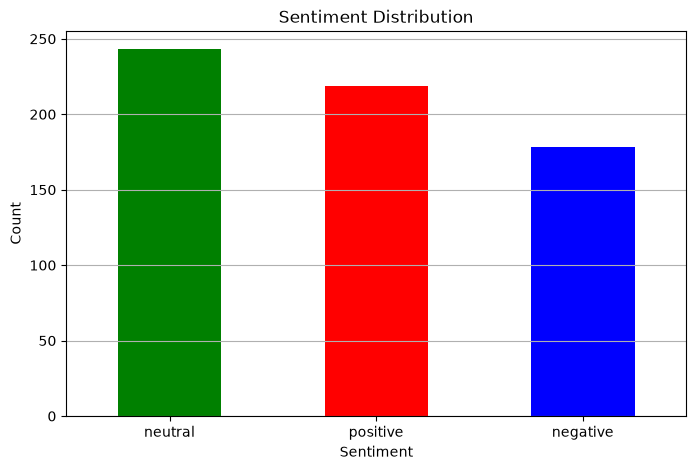

sentiment
neutral     243
positive    219
negative    178
Name: count, dtype: int64


In [39]:
import matplotlib.pyplot as plt

sentiment_counts = data['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

print(sentiment_counts)

In [40]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Yohanes
[nltk_data]     Joni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


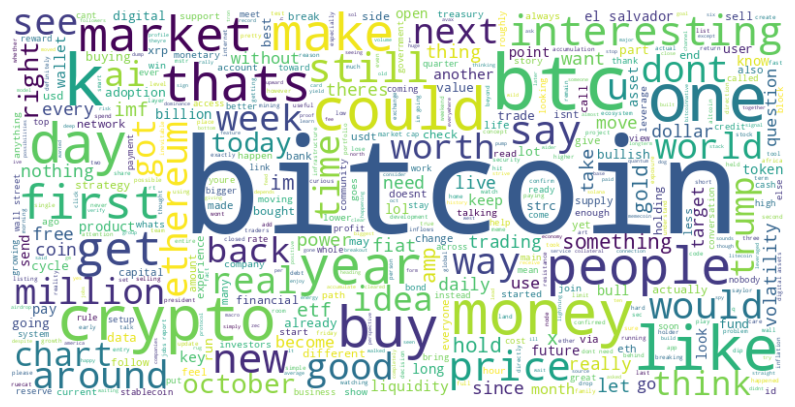

In [41]:
#wordcloud
data_text = ' '.join(data['full_text'].astype(str).tolist())

#generate word cloud
wc = WordCloud(stopwords=stopwords, background_color='white', max_words=500 ,width=800, height=400).generate(data_text)

#Tampilkan wordcloud 
plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

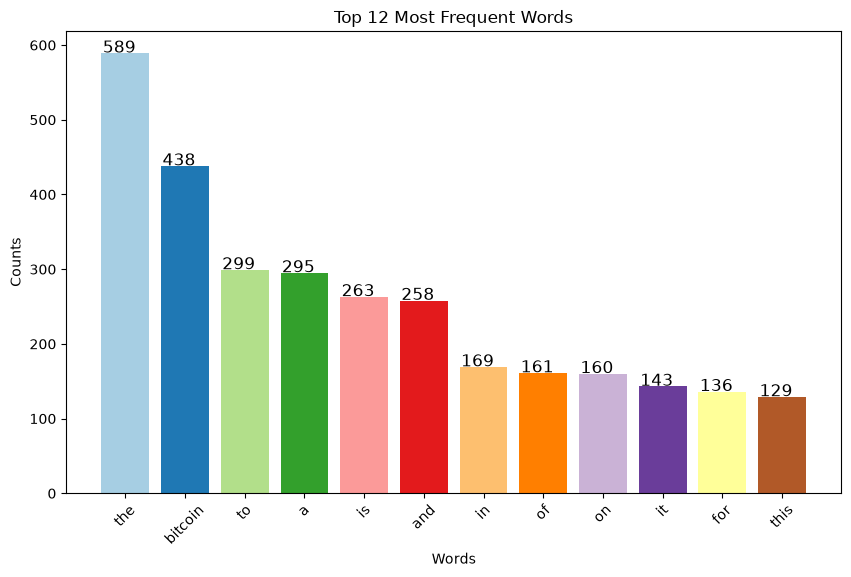

In [42]:
#Bar chart kata yang paling sering muncul

text = ' '.join(data['full_text'].astype(str).tolist())
words = text.split()

# Hitung frekuensi kata
word_counts = Counter(words)

#Ambil 12 kata yang paling sering muncul
top_words = word_counts.most_common(12)

words, counts = zip(*top_words)

#Buat bar chart
colors = plt.cm.Paired(range(len(words)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(words, counts, color=colors)

ax.set_xlabel('Words')
ax.set_ylabel('Counts') 
ax.set_title('Top 12 Most Frequent Words')
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=45)

#Tambahkan label di atas setiap bar
for bar, num in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')
     
#Tampilkan bar chart
plt.show() 